In [1]:
import pyxdf 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [4]:
file_path=r"C:\Users\abolhassni\Desktop\TU Darmstadt\Term3\ANSYMB\LSL\imu_motion_capture_analysis\data\raw\TEST 27 MAI\abduction.xdf"

streams_abd, header_abd=pyxdf.load_xdf(file_path)



In [5]:
print("Number of streams:", len(streams_abd))

for i, stream in enumerate(streams_abd):
    name = stream["info"]["name"][0]
    data = stream["time_series"]
    time = stream["time_stamps"]

    print("Index:", i)
    print("Name:", name)
    print("Data shape:", data.shape)
    print("Time shape:", time.shape)

    if len(time) > 1:
        duration = time[-1] - time[0]
        fs_estimated = (len(time) - 1) / duration
        print("Duration:", duration)
        print("Estimated sampling rate:", fs_estimated)

    print("--------------------")

Number of streams: 4
Index: 0
Name: Xsens_MTw2_00B4D0C5
Data shape: (2435, 15)
Time shape: (2435,)
Duration: 24.526013093302026
Estimated sampling rate: 99.24156815624947
--------------------
Index: 1
Name: Xsens_MTw2_00B4D0C8
Data shape: (2443, 15)
Time shape: (2443,)
Duration: 24.54687109554652
Estimated sampling rate: 99.48314758710922
--------------------
Index: 2
Name: Xsens_MTw2_00B4D0BE
Data shape: (2443, 15)
Time shape: (2443,)
Duration: 24.56557917263126
Estimated sampling rate: 99.40738554703627
--------------------
Index: 3
Name: Xsens_MTw2_00B4D0D0
Data shape: (2440, 15)
Time shape: (2440,)
Duration: 24.522622575925197
Estimated sampling rate: 99.45918273824677
--------------------


In [6]:
columns = [
    "qw", "qx", "qy", "qz",
    "ax", "ay", "az",
    "gx", "gy", "gz",
    "mx", "my", "mz",
    "packet_counter",
    "sample_time_fine"
]

sensor_dfs_abd = {}

for stream in streams_abd:
    sensor_name = stream["info"]["name"][0]
    data = stream["time_series"]
    time = stream["time_stamps"]

    df = pd.DataFrame(data, columns=columns)
    df["time_stamp"] = time
    df["time_insert"] = time - time[0]

    sensor_dfs_abd[sensor_name] = df

sensor_dfs_abd.keys()

dict_keys(['Xsens_MTw2_00B4D0C5', 'Xsens_MTw2_00B4D0C8', 'Xsens_MTw2_00B4D0BE', 'Xsens_MTw2_00B4D0D0'])

In [7]:
sensor_map = {
    "Xsens_MTw2_00B4D0C5": "Pelv",
    "Xsens_MTw2_00B4D0BE": "lLeg_L",
    "Xsens_MTw2_00B4D0C8": "uLeg_L",
    "Xsens_MTw2_00B4D0D0": "Foot_L"
}

sensor_dfs_abd_mapped = {}

for sensor_id, body_name in sensor_map.items():
    if sensor_id in sensor_dfs_abd:
        sensor_dfs_abd_mapped[body_name] = sensor_dfs_abd[sensor_id]

sensor_dfs_abd_mapped.keys()

dict_keys(['Pelv', 'lLeg_L', 'uLeg_L', 'Foot_L'])

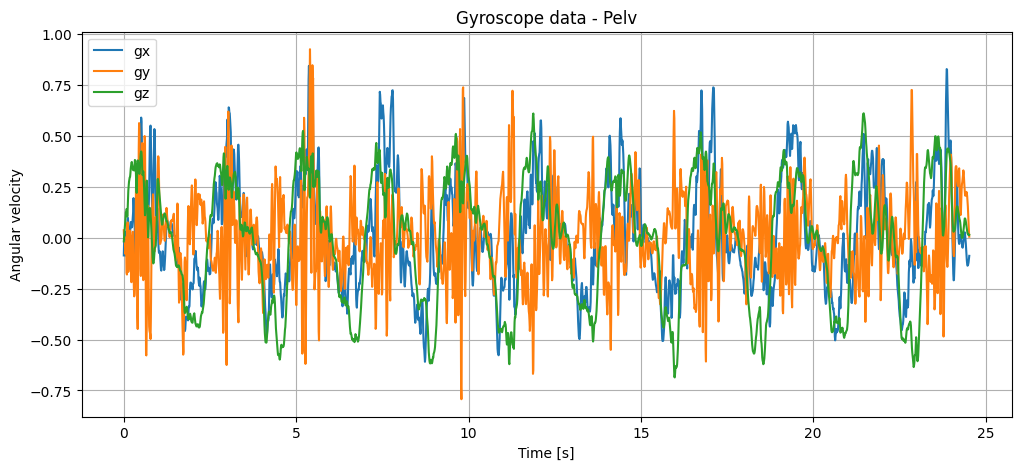

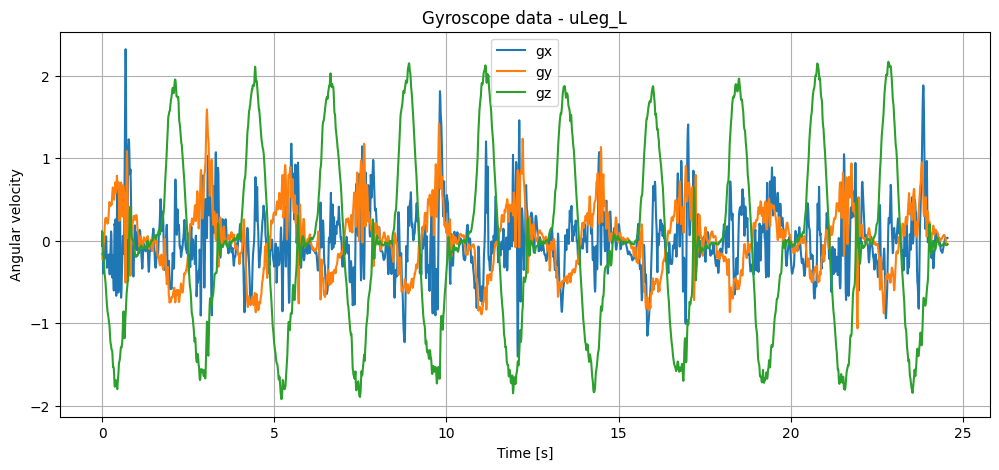

In [8]:
for sensor_name in ["Pelv", "uLeg_L"]:
    df = sensor_dfs_abd_mapped[sensor_name]
    t = df["time_insert"]

    plt.figure(figsize=(12, 5))
    plt.plot(t, df["gx"], label="gx")
    plt.plot(t, df["gy"], label="gy")
    plt.plot(t, df["gz"], label="gz")

    plt.xlabel("Time [s]")
    plt.ylabel("Angular velocity")
    plt.title(f"Gyroscope data - {sensor_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [9]:
t_start = 0
t_end = sensor_dfs_abd_mapped["uLeg_L"]["time_insert"].max()

for sensor_name in ["Pelv", "uLeg_L"]:
    df = sensor_dfs_abd_mapped[sensor_name]

    df_move = df[
        (df["time_insert"] >= t_start) &
        (df["time_insert"] <= t_end)
    ]

    gyro_rms = np.sqrt((df_move[["gx", "gy", "gz"]] ** 2).mean())

    print(sensor_name)
    print(gyro_rms)
    print("Dominant axis:", gyro_rms.idxmax())
    print("--------------------")

Pelv
gx    0.260707
gy    0.199359
gz    0.300747
dtype: float32
Dominant axis: gz
--------------------
uLeg_L
gx    0.392263
gy    0.400137
gz    1.064474
dtype: float32
Dominant axis: gz
--------------------


In [10]:
def dominant_rotation_axis(df, t_start, t_end):
    df_move = df[
        (df["time_insert"] >= t_start) &
        (df["time_insert"] <= t_end)
    ]

    W = df_move[["gx", "gy", "gz"]].to_numpy()
    W = W - W.mean(axis=0)

    U, S, Vt = np.linalg.svd(W, full_matrices=False)

    axis = Vt[0]
    axis = axis / np.linalg.norm(axis)

    explained_variance = S[0]**2 / np.sum(S**2)

    return axis, explained_variance

In [11]:
for sensor_name in ["Pelv", "uLeg_L"]:
    axis, explained = dominant_rotation_axis(
        sensor_dfs_abd_mapped[sensor_name],
        t_start,
        t_end
    )

    print(sensor_name)
    print("Dominant rotation axis:", axis)
    print("Explained variance:", round(explained, 3))
    print("--------------------")

Pelv
Dominant rotation axis: [ 0.62167567 -0.12886171  0.77260214]
Explained variance: 0.703
--------------------
uLeg_L
Dominant rotation axis: [ 0.04600234  0.31687117 -0.94735235]
Explained variance: 0.869
--------------------
